# Part 1

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids, TomekLinks
from imblearn.over_sampling import RandomOverSampler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

In [ ]:
print(f'DF Shape: {df.shape}')

DF Shape: (5110, 12)


In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
df.describe(include='all')

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f'Numerical columns: {numeric_cols}')
print(f'Categorical columns: {categorical_cols}')

Numerical columns: ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
Categorical columns: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [ ]:
corr_matrix = df[numeric_cols].corr()
print(f'Correlation Matrix:\n {corr_matrix}')

Correlation Matrix:
                          id       age  hypertension  heart_disease  \
id                 1.000000  0.003538      0.003550      -0.001296   
age                0.003538  1.000000      0.276398       0.263796   
hypertension       0.003550  0.276398      1.000000       0.108306   
heart_disease     -0.001296  0.263796      0.108306       1.000000   
avg_glucose_level  0.001092  0.238171      0.174474       0.161857   
bmi                0.003084  0.333398      0.167811       0.041357   
stroke             0.006388  0.245257      0.127904       0.134914   

                   avg_glucose_level       bmi    stroke  
id                          0.001092  0.003084  0.006388  
age                         0.238171  0.333398  0.245257  
hypertension                0.174474  0.167811  0.127904  
heart_disease               0.161857  0.041357  0.134914  
avg_glucose_level           1.000000  0.175502  0.131945  
bmi                         0.175502  1.000000  0.042374  
strok

<p style=color:red;> The highest  correlation shown in the correlation matrix is between Age and BMI (r = 0.33) which gives a meaningful indication that with aging BMI increases.</p>

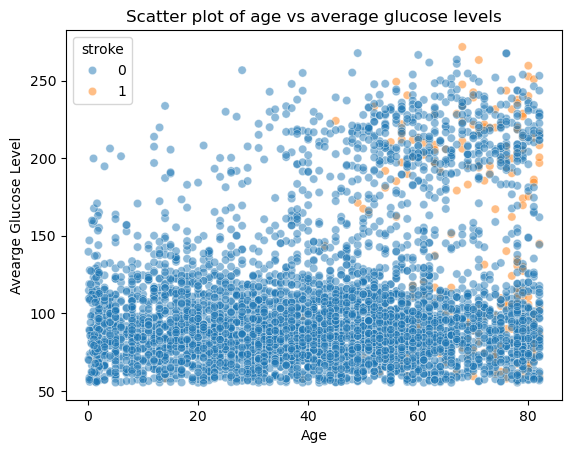

In [ ]:
sns.scatterplot(df, x= df['age'], y=df['avg_glucose_level'] , hue= 'stroke', alpha=0.5)
plt.title('Scatter plot of age vs average glucose levels')
plt.ylabel('Avearge Glucose Level')
plt.xlabel('Age')
plt.show()

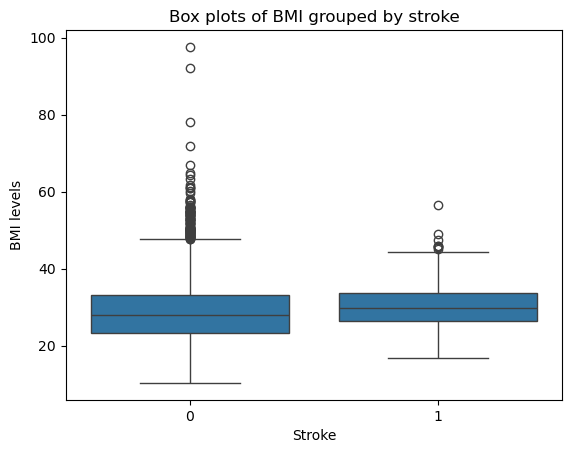

In [ ]:
sns.boxplot(df, x='stroke', y='bmi')
plt.title('Box plots of BMI grouped by stroke')
plt.ylabel('BMI levels')
plt.xlabel('Stroke')
plt.show()

In [ ]:
df[['smoking_status']] = df[['smoking_status']].replace('Unknown', np.nan)

In [ ]:
print(f'Missing value counts: \n{df.isna().sum()}')
print(f'\nMissing value percentages: \n{(df.isna().sum()/len(df) )*100}')

Missing value counts: 
id                      0
gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
Residence_type          0
avg_glucose_level       0
bmi                   201
smoking_status       1544
stroke                  0
dtype: int64

Missing value percentages: 
id                    0.000000
gender                0.000000
age                   0.000000
hypertension          0.000000
heart_disease         0.000000
ever_married          0.000000
work_type             0.000000
Residence_type        0.000000
avg_glucose_level     0.000000
bmi                   3.933464
smoking_status       30.215264
stroke                0.000000
dtype: float64


In [ ]:
print(f'Number of duplicates: {df.duplicated().sum()}')

Number of duplicates: 0


In [ ]:
df_listwise = df.dropna()
print(f'Rows before deletion: {len(df)}, Rows after deletion: {len(df_listwise)}')

Rows before deletion: 5110, Rows after deletion: 3426


In [ ]:
num_imputer = SimpleImputer(strategy= 'median')
cat_imputer = SimpleImputer(strategy= 'most_frequent')
df_imputed = df.copy()
df_imputed[['bmi']] = num_imputer.fit_transform(df_imputed[['bmi']])
df_imputed[['smoking_status']] = cat_imputer.fit_transform(df_imputed[['smoking_status']])

In [ ]:
print(df_imputed[['bmi','smoking_status']].isna().sum())

bmi               0
smoking_status    0
dtype: int64


In [ ]:
 df_imputed.to_csv('cleaned_stroke.csv')

# Part 2

In [ ]:
X = df_imputed[['age','hypertension','heart_disease','avg_glucose_level','bmi']]
y = df_imputed['stroke']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

In [ ]:
std = StandardScaler()
std.fit(X_train)
X_train_std = std.transform(X_train)
X_test_std  = std.transform(X_test)

In [ ]:
minmax = MinMaxScaler()
minmax.fit(X_train)
X_train_norm = minmax.transform(X_train)
X_test_norm  = minmax.transform(X_test)

In [ ]:
r1 = X_test.iloc[0]
r2 = X_test.iloc[1]
dist = np.linalg.norm(r1 - r2)

r1_std = X_test_std[0]
r2_std = X_test_std[1]
dist_std = np.linalg.norm(r1_std - r2_std)


r1_norm = X_test_norm[0]
r2_norm = X_test_norm[1]
dist_norm = np.linalg.norm(r1_norm - r2_norm)

print(f'Distance before scaling: {dist}')
print(f'Distance after standardization: {dist_std}')
print(f'Distance after normalization: {dist_norm}')

Distance before scaling: 21.759678306445615
Distance after standardization: 0.9250310594542693
Distance after normalization: 0.2478264037151181


In [ ]:
print(f'Value Counts for {y_train.value_counts()}')
print(f'\nClass prportions  for {y_train.value_counts(normalize =True)}')

Value Counts for stroke
0    3889
1     199
Name: count, dtype: int64

Class prportions  for stroke
0    0.951321
1    0.048679
Name: proportion, dtype: float64


In [ ]:
from sklearn.dummy import DummyClassifier
dummy =  DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

,strategy,'most_frequent'
,random_state,42
,constant,None


In [ ]:
y_pred = dummy.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

In [ ]:
print(f'Dummy classifier accuracy: {accuracy}')
print(f'Dummy classifier recall: {recall}')

Dummy classifier accuracy: 0.9510763209393346
Dummy classifier recall: 0.0


<p style=color:red;>The model shows a high accuracy because it is predicting the most frequent value (0) and because the classes are highly imbalanced but the recall metric which shows the percentage of positives correctly identified, i.e. stroke/the minority class, is zero for the same reason, i.e. the classifier labels all instances as negative so no positive instances are detected.</p>

In [ ]:
lr =  LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
#The notes mentiones fitting on scaled X_train but didn't specify the scaling method, so I'll use the standardized one
lr.fit(X_train_std , y_train)
y_pred = lr.predict(X_test_std)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



C:\Applications\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Applications\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Applications\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Confusion matrix:
 [[972   0]
 [ 50   0]]


<h2 style=color:red;>Under-sampling</h2>

In [ ]:
rus = RandomUnderSampler(random_state=42)
Xr, yr = rus.fit_resample(X_train_std, y_train)

In [ ]:
print(f'Value counts for classes after under-sampling:\n {yr.value_counts()}')

Value counts for classes after under-sampling:
 stroke
0    199
1    199
Name: count, dtype: int64


In [ ]:
lr2 =  LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(Xr, yr)
y_pred2 = lr2.predict(X_test_std)

In [ ]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.82      1022



In [ ]:
recall2 = recall_score(y_test, y_pred2)
print(f'LR recall before under-sampling: {recall}')
print(f'LR recall after under-sampling: {recall2}')

LR recall before under-sampling: 0.0
LR recall after under-sampling: 0.8


<p style=color:red;>The output shows the differnce in recall before and after under-sampling. After the two classes became balanced, the model performance in distinguishing positive instances improved, therefore the recall went up to 80% which was 0% before resampling.</p>

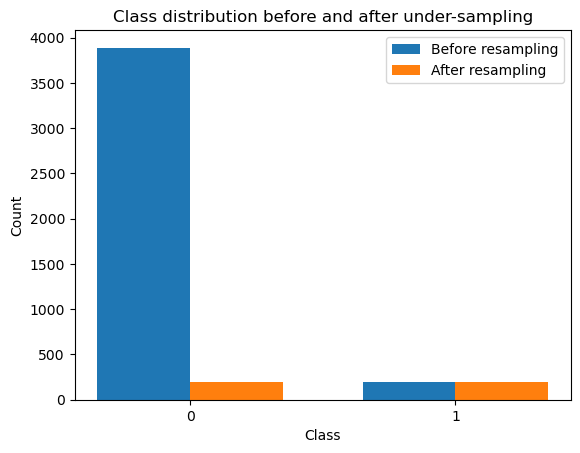

In [ ]:
before_counts = np.bincount(y_train)
after_counts = np.bincount(yr)

x = np.arange(len(before_counts))
width = 0.35

plt.figure()
plt.bar(x - width/2, before_counts, width, label='Before resampling')
plt.bar(x + width/2, after_counts, width, label='After resampling')

plt.title('Class distribution before and after under-sampling')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(x)
plt.legend()
plt.show()
